##### CUSTOMER CHURN PREDICTION USING MACHINE LEARNING

In [61]:
# IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

##### LOAD DATASET

In [62]:
# Load IBM Telco Customer Churn Dataset

df = pd.read_csv(
    "/content/WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


##### DATA UNDERSTANDING

In [ ]:
# Dataset information

df.info()

# Dataset shape

df.shape

# Statistical summary

df.describe()

# Missing values

df.isnull().sum()

# Duplicate records

df.duplicated().sum()

##### DATA CLEANING

In [63]:
# Convert TotalCharges to numeric

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)
# Replace the TotalCharges invalid rows with median value
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

# Remove customerID because it does not contribute to churn prediction
df.drop("customerID", axis=1, inplace=True)


##### NOTE: Duplicate records can bias the model by overrepresenting specific customer profiles and influencing model learning. Therefore, duplicate observations were checked before training.


##### EXPLORATORY DATA ANALYSIS (EDA)

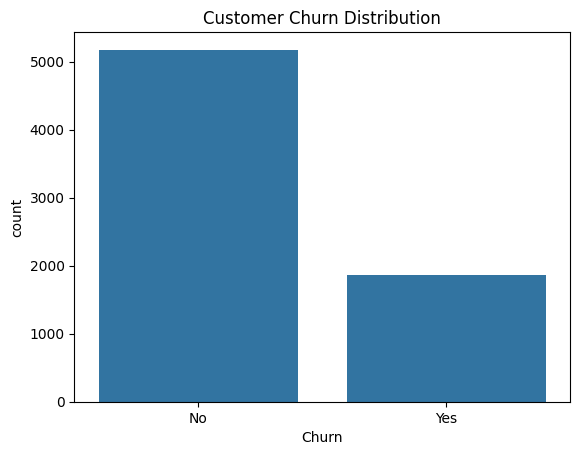

In [64]:
# Churn Distribution Analysis

df["Churn"].value_counts()

churn_dist = (
    df["Churn"]
    .value_counts(normalize=True)
    * 100
).round(2)

churn_dist.astype(str) + "%"

sns.countplot(
    x="Churn",
    data=df
)

plt.title("Customer Churn Distribution")
plt.show()



##### Key Findings:
The dataset is imbalanced, with approximately 73% of customers remaining with the company and 27% of customers churning.


##### NUMERICAL FEATURE ANALYSIS

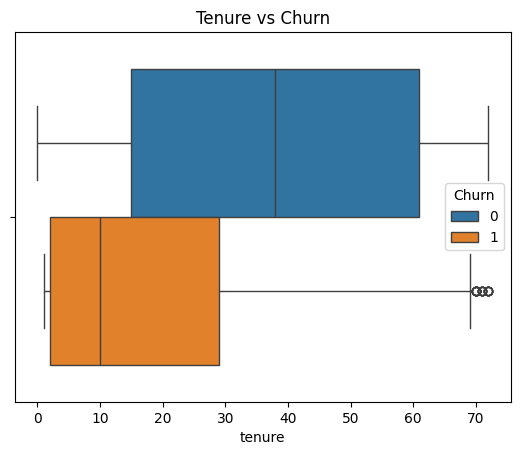

In [65]:
# Convert Target Variable
df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

# Correlation Analysis
df.corr(numeric_only=True)

sns.boxplot(
    x="tenure",
    hue="Churn",
    data=df
)

plt.title("Tenure vs Churn")
plt.show()


##### Key Findings:

Correlation analysis showed that tenure had the strongest negative relationship with churn.

Customers with longer tenure were significantly less likely to leave the company.

MonthlyCharges and SeniorCitizen showed weak positive relationships with churn.


##### CATEGORICAL FEATURES ANALYSIS

In [66]:
# One-Hot Encoding

categorical_cols = (
    df.select_dtypes(
        include="object"
    ).columns
)

df = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)

# # Feature Correlations
# df.corr()["Churn"]


# # Monthly Charges vs Churn

# plt.figure(figsize=(10,5))

# sns.boxplot(
#     x="MonthlyCharges",
#     hue="Churn",
#     data=df
# )

# plt.title("Monthly Charges vs Churn")
# plt.show()

# # Total Charges vs Churn

# plt.figure(figsize=(10,5))

# sns.boxplot(
#     x="TotalCharges",
#     hue="Churn",
#     data=df
# )

# plt.title("Total Charges vs Churn")
# plt.show()


##### FEATURE SELECTION

In [67]:
# Define features and label
X = df.drop(
    "Churn",
    axis=1
)

y = df["Churn"]

##### TRAIN-TEST SPLIT



In [68]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Export Testing Dataset for Deployment
# Optional

# test_df = pd.concat(
#     [X_test, y_test],
#     axis=1
# )

# test_df.to_csv(
#     "test_data.csv",
#     index=False
# )

##### FEATURE SCALING



In [69]:
scaler = StandardScaler()

In [70]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
features = X.columns.tolist()

##### MODEL TRAINING

In [71]:
# Logistic Regression Classifier
model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight="balanced")

model.fit(X_train,y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

##### CHURN PREDICTION

In [76]:
y_proba = model.predict_proba(X_test)[:,1]

# Threshold Optimisation
threshold = 0.48

y_pred = (y_proba >= threshold).astype(int)


##### NOTE:
A threshold of 0.48 was selected instead of the default 0.50 to improve churn detection performance and maximize recall.


##### MODEL EVALUATION

In [77]:
accuracy = accuracy_score(y_test,y_pred)
print("Accuracy:", accuracy)
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(roc_auc_score(y_test,y_proba))


Accuracy: 0.7430801987224982
              precision    recall  f1-score   support

           0       0.93      0.71      0.80      1036
           1       0.51      0.85      0.64       373

    accuracy                           0.74      1409
   macro avg       0.72      0.78      0.72      1409
weighted avg       0.82      0.74      0.76      1409

[[731 305]
 [ 57 316]]
0.8619031229621043


##### NOTE:
The model demonstrates strong discriminatory power with an ROC-AUC score of 0.862.

Recall was prioritised because identifying customers likely to churn is more valuable for retention planning than minimising false positives.

##### SAVE MODEL FOR DEPLOYMENT

In [ ]:
# Save model
pickle.dump(model,open("model.pkl","wb"))
# Save scaler
pickle.dump(scaler,open("scaler.pkl","wb"))
# Save features
pickle.dump(features,open("features.pkl","wb"))
